# EXP-003 | 피처 엔지니어링 v1

EDA 인사이트를 반영한 전처리 개선 + 파생 피처 추가.
학습 완료 후 `docs/leaderboard.xlsx`에 자동 기록됩니다.

| 항목 | 내용 |
|---|---|
| 기반 실험 | EXP-002 (LightGBM 전체 피처, OOF 0.73887) |
| 모델 | LightGBM |
| CV | Stratified 5-Fold |

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve
import lightgbm as lgb

from src.preprocessing import preprocess

warnings.filterwarnings('ignore')
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path('../data/raw')
OUT_DIR  = Path('../data/submissions')
DOCS_DIR = Path('../docs')

TARGET  = '임신 성공 여부'
ID_COL  = 'ID'
SEED    = 42
N_FOLDS = 5

# ── 실험 메타데이터 (실험마다 수정) ─────────────────────────────────────────
EXP_NO      = 3
AUTHOR      = '조여진'
MODEL_NAME  = 'LightGBM'
CV_STR      = f'Stratified {N_FOLDS}-Fold'
KEY_CHANGES = ('FE v1: 상수 컬럼 2개 제거, PGD/PGS/유전검사 결측→0 재코딩, '
               '파생 피처 13개 추가(수정률·이식률·불임원인 합산 등)')

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')
sub   = pd.read_csv(DATA_DIR / 'sample_submission.csv')
print(f'train: {train.shape}  /  test: {test.shape}')

train: (256351, 69)  /  test: (90067, 68)


## 1. EDA 인사이트 요약

### 제거 대상 (예측력 0)
| 컬럼 | 이유 |
|---|---|
| `불임 원인 - 여성 요인` | 전체 256,351행 모두 0 — 상수 컬럼 |
| `난자 채취 경과일` | 전체 행 모두 0 — 상수 컬럼 |

### 결측=미시행(0) 재코딩 대상
비결측값이 전부 1이므로 **결측=미시행** 의미 → 제거하지 않고 0으로 채워 이진 피처로 활용

| 컬럼 | 비결측 건수 | 재코딩 후 의미 |
|---|---|---|
| `착상 전 유전 검사 사용 여부` | 2,718행 | 1=PGS 검사 시행, 0=미시행 |
| `PGD 시술 여부` | 2,179행 | 1=PGD 시행, 0=미시행 |
| `PGS 시술 여부` | 1,929행 | 1=PGS 시행, 0=미시행 |

### 주요 수치 피처 (타겟과 강한 관계)
- `혼합된 난자 수`, `파트너 정자와 혼합된 난자 수`, `총 생성 배아 수`, `수집된 신선 난자 수`
  → 성공군이 실패군보다 평균 1.4~1.7개 높음
- `배아 이식 경과일`: 성공군이 약 0.55일 더 김 (배반포 단계 이식 가능성)
- `저장된 신선 난자 수`: 성공군 0.005 vs 실패군 0.125 — 저장 없이 바로 이식 시 성공률 높음

### 배아 생성 주요 이유 (복수선택, 분리 집계)
- `현재 시술용` (27.5%), `기증용` (28.4%) → 성공률 높음
- `난자 저장용`, `배아 저장용` → 성공률 ~0% (현재 임신 목적 아님)

### 클래스 불균형
- 실패:성공 = 2.87:1 (실패 74.2% / 성공 25.8%) → `is_unbalance=True` 유지

## 2. 파생 피처 엔지니어링

In [3]:
# 기증 여부 플래그: 난자/정자 출처 원본 문자열이 필요하므로 preprocess() 호출 전에 생성
def add_pre_encode_features(df):
    df = df.copy()
    df['기증_난자_여부'] = (df['난자 출처'] == '기증 제공').astype(int)
    df['기증_정자_여부'] = df['정자 출처'].isin(
        ['기증 제공', '배우자 및 기증 제공']).astype(int)
    return df


# 수치형 파생 피처: 전처리 후 수치 컬럼만 남은 상태에서 생성
def add_derived_features(df):
    df = df.copy()
    eps = 1e-6

    df['수정률']    = df['총 생성 배아 수']    / (df['혼합된 난자 수'] + eps)
    df['이식률']    = df['이식된 배아 수']     / (df['총 생성 배아 수'] + eps)
    df['저장률']    = df['저장된 배아 수']     / (df['총 생성 배아 수'] + eps)
    df['ICSI_비율'] = df['미세주입된 난자 수']  / (df['혼합된 난자 수'] + eps)
    df['배아_발달일'] = df['배아 이식 경과일'] - df['난자 혼합 경과일']
    df['신선_시술_여부'] = df['수집된 신선 난자 수'].notna().astype(int)

    male_cols   = ['남성 주 불임 원인', '남성 부 불임 원인', '불임 원인 - 남성 요인']
    female_cols = ['여성 주 불임 원인', '여성 부 불임 원인',
                   '불임 원인 - 난관 질환', '불임 원인 - 배란 장애',
                   '불임 원인 - 자궁내막증', '불임 원인 - 자궁경부 문제']
    couple_cols = ['부부 주 불임 원인', '부부 부 불임 원인']
    sperm_cols  = ['불임 원인 - 정자 농도', '불임 원인 - 정자 운동성',
                   '불임 원인 - 정자 형태', '불임 원인 - 정자 면역학적 요인']
    all_cause   = male_cols + female_cols + couple_cols + sperm_cols + ['불명확 불임 원인']

    df['남성_불임_합계'] = df[male_cols].sum(axis=1)
    df['여성_불임_합계'] = df[female_cols].sum(axis=1)
    df['부부_불임_합계'] = df[couple_cols].sum(axis=1)
    df['정자_문제_합계'] = df[sperm_cols].sum(axis=1)
    df['총_불임원인_수'] = df[all_cause].sum(axis=1)

    # EDA 추가 인사이트
    df['임신시도기록_있음'] = df['임신 시도 또는 마지막 임신 경과 연수'].notna().astype(int)
    df['신선_난자_저장_있음'] = (df['저장된 신선 난자 수'] > 0).astype(int)
    df['나이_시술횟수_상호작용'] = df['시술 당시 나이'] * df['총 시술 횟수']

    return df


print('파생 피처 함수 정의 완료')

파생 피처 함수 정의 완료


In [4]:
# ── 전처리 파이프라인 ─────────────────────────────────────────────────────────
# 1단계: 인코딩 전 피처 (원본 문자열 필요)
train_fe = add_pre_encode_features(train)
test_fe  = add_pre_encode_features(test)

# 2단계: 공통 전처리 (src/preprocessing.py)
X_train, X_test = preprocess(train_fe, test_fe)

# 3단계: 수치형 파생 피처
X_train = add_derived_features(X_train)
X_test  = add_derived_features(X_test)

y_train = train[TARGET]

print(f'X_train: {X_train.shape}  /  X_test: {X_test.shape}')
print(f'결측 컬럼 수: {X_train.isnull().any().sum()}개  (LightGBM NaN 자동 처리)')
print(f'EXP-002(71개) 대비 Δ피처: {X_train.shape[1] - 71:+d}개')

X_train: (256351, 85)  /  X_test: (90067, 85)
결측 컬럼 수: 30개  (LightGBM NaN 자동 처리)
EXP-002(71개) 대비 Δ피처: +14개


## 3. 모델 학습 (LightGBM Stratified 5-Fold)

In [5]:
LGB_PARAMS = dict(
    objective         = 'binary',
    metric            = 'auc',
    learning_rate     = 0.05,
    num_leaves        = 127,
    max_depth         = -1,
    min_child_samples = 50,
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 1,
    lambda_l1         = 0.1,
    lambda_l2         = 0.1,
    is_unbalance      = True,
    verbosity         = -1,
    seed              = SEED,
)

skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
fold_aucs  = []
models     = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    ds_tr  = lgb.Dataset(X_tr, label=y_tr)
    ds_val = lgb.Dataset(X_val, label=y_val, reference=ds_tr)

    model = lgb.train(
        LGB_PARAMS,
        ds_tr,
        num_boost_round = 2000,
        valid_sets      = [ds_val],
        callbacks       = [
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )

    val_prob = model.predict(X_val)
    auc      = roc_auc_score(y_val, val_prob)
    fold_aucs.append(auc)
    oof_preds[val_idx] = val_prob
    test_preds        += model.predict(X_test) / N_FOLDS
    models.append(model)

    print(f'  Fold {fold}  best_iter={model.best_iteration:4d}  AUC={auc:.5f}')

oof_auc = roc_auc_score(y_train, oof_preds)
print()
print(f'OOF ROC-AUC : {oof_auc:.5f}')
print(f'Fold 평균   : {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}')
print()
print(f'EXP-002 OOF : 0.73887  →  EXP-003 OOF : {oof_auc:.5f}  '
      f'(Δ {oof_auc - 0.73887:+.5f})')

  Fold 1  best_iter= 111  AUC=0.73658
  Fold 2  best_iter= 103  AUC=0.74144
  Fold 3  best_iter=  85  AUC=0.73895
  Fold 4  best_iter=  63  AUC=0.73752
  Fold 5  best_iter=  90  AUC=0.73912

OOF ROC-AUC : 0.73864
Fold 평균   : 0.73872 ± 0.00165

EXP-002 OOF : 0.73887  →  EXP-003 OOF : 0.73864  (Δ -0.00023)


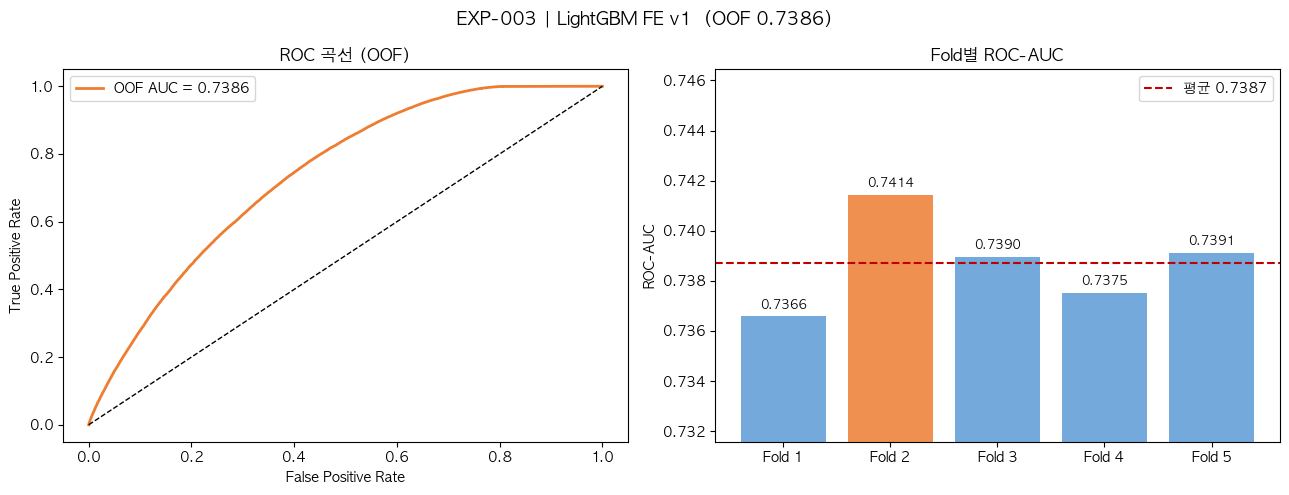

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC 곡선
fpr, tpr, _ = roc_curve(y_train, oof_preds)
axes[0].plot(fpr, tpr, color='#ED7D31', lw=2, label=f'OOF AUC = {oof_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC 곡선 (OOF)')
axes[0].legend()

# Fold별 AUC
colors = ['#ED7D31' if v == max(fold_aucs) else '#5B9BD5' for v in fold_aucs]
axes[1].bar([f'Fold {i}' for i in range(1, N_FOLDS + 1)], fold_aucs,
            color=colors, alpha=0.85)
axes[1].axhline(np.mean(fold_aucs), color='#C00000', linestyle='--',
                label=f'평균 {np.mean(fold_aucs):.4f}')
axes[1].set_ylim(min(fold_aucs) - 0.005, max(fold_aucs) + 0.005)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Fold별 ROC-AUC')
axes[1].legend()
for i, v in enumerate(fold_aucs):
    axes[1].text(i, v + 0.0003, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle(f'EXP-003 | LightGBM FE v1  (OOF {oof_auc:.4f})', fontsize=13)
plt.tight_layout()
plt.show()

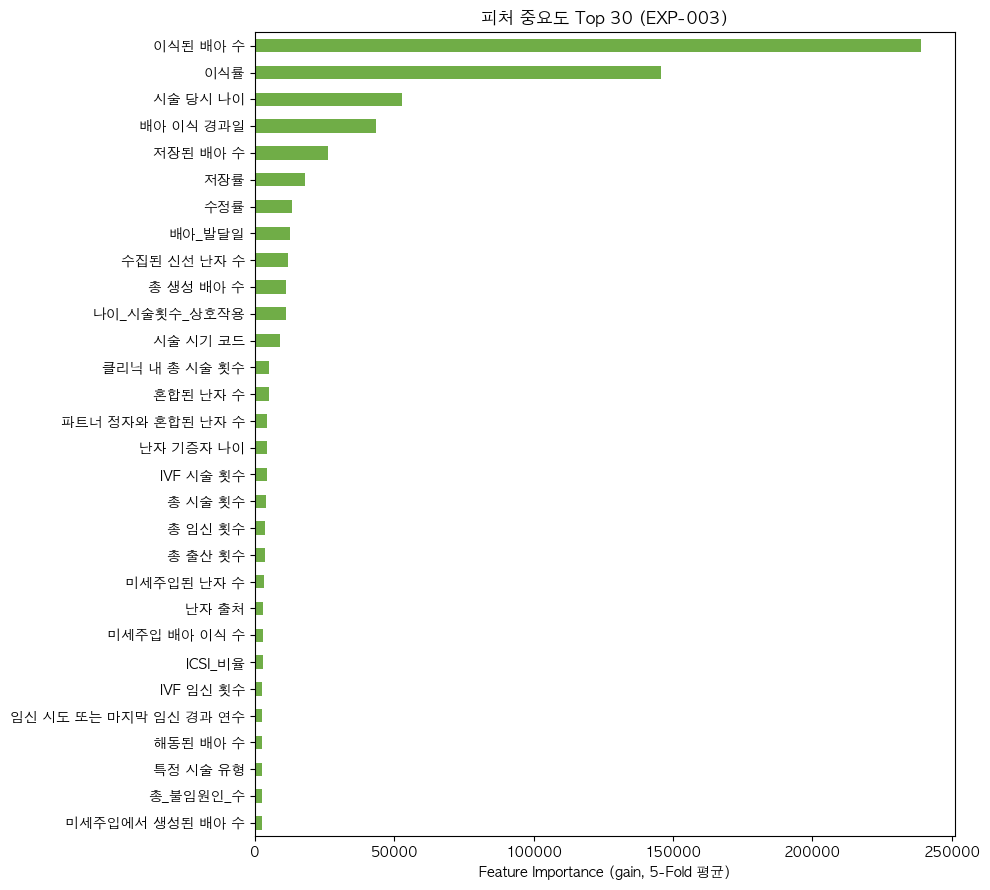


[파생 피처 중요도 순위]
  이식률                gain= 145687.5  전체 순위=2위
  저장률                gain=  18124.7  전체 순위=6위
  수정률                gain=  13351.0  전체 순위=7위
  배아_발달일             gain=  12553.2  전체 순위=8위
  ICSI_비율            gain=   2785.8  전체 순위=24위
  총_불임원인_수           gain=   2582.5  전체 순위=29위
  여성_불임_합계           gain=   2069.9  전체 순위=33위
  기증_난자_여부           gain=   2041.1  전체 순위=34위
  남성_불임_합계           gain=   1151.3  전체 순위=40위
  부부_불임_합계           gain=    227.2  전체 순위=57위
  기증_정자_여부           gain=     79.4  전체 순위=69위
  정자_문제_합계           gain=      5.1  전체 순위=75위
  신선_시술_여부           gain=      0.0  전체 순위=81위


In [7]:
# 전체 Fold 평균 importance
importance_gain = np.zeros(X_train.shape[1])
for m in models:
    importance_gain += m.feature_importance(importance_type='gain')
importance_gain /= N_FOLDS

importance = pd.Series(importance_gain, index=X_train.columns)
importance = importance.sort_values(ascending=False)

top30 = importance.head(30)
fig, ax = plt.subplots(figsize=(10, 9))
top30[::-1].plot(kind='barh', ax=ax, color='#70AD47')
ax.set_xlabel('Feature Importance (gain, 5-Fold 평균)')
ax.set_title('피처 중요도 Top 30 (EXP-003)')
plt.tight_layout()
plt.show()

print('\n[파생 피처 중요도 순위]')
derived = ['수정률', '이식률', '저장률', 'ICSI_비율', '배아_발달일', '신선_시술_여부',
           '남성_불임_합계', '여성_불임_합계', '부부_불임_합계', '정자_문제_합계',
           '총_불임원인_수', '기증_난자_여부', '기증_정자_여부']
derived_imp = importance[importance.index.isin(derived)].sort_values(ascending=False)
rank_all = importance.rank(ascending=False).astype(int)
for col, val in derived_imp.items():
    print(f'  {col:<18} gain={val:9.1f}  전체 순위={rank_all[col]}위')

## 4. Submission 저장

In [8]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
sub['probability'] = test_preds

auc_str  = f'{oof_auc:.4f}'.replace('.', '')
out_fname = f'submission_exp{EXP_NO:03d}_{AUTHOR}_{auc_str}.csv'
out_path  = OUT_DIR / out_fname
sub.to_csv(out_path, index=False)

print(f'저장 완료: {out_path}')
print()
print(sub['probability'].describe().round(4))

저장 완료: ../data/submissions/submission_exp003_조여진_07386.csv

count    90067.0000
mean         0.4460
std          0.2343
min          0.0054
25%          0.3164
50%          0.5084
75%          0.6271
max          0.8456
Name: probability, dtype: float64


## 5. 자동 실험 기록 → `docs/leaderboard.xlsx`

- **Public AUC** 칸은 데이콘 제출 후 직접 입력
- 기존 행이 있으면 첫 번째 빈 행에 자동 삽입

In [9]:
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from datetime import date

# ── threshold=0.5 기준 분류 지표 계산 (참고용) ───────────────────────────────
oof_binary = (oof_preds >= 0.5).astype(int)
f1       = f1_score(y_train, oof_binary)
recall   = recall_score(y_train, oof_binary)
precision = precision_score(y_train, oof_binary)
accuracy = accuracy_score(y_train, oof_binary)

print(f'[OOF 분류 지표 — threshold=0.5]')
print(f'  AUC-ROC   : {oof_auc:.5f}  ← 대회 평가 지표')
print(f'  F1        : {f1:.5f}')
print(f'  Recall    : {recall:.5f}')
print(f'  Precision : {precision:.5f}')
print(f'  Accuracy  : {accuracy:.5f}')
print()

# ── 실험 기록 설정 ────────────────────────────────────────────────────────────
PREPROCESSING_VER  = 'v1'
IMBALANCE_METHOD   = 'is_unbalance=True'
SUBMITTED          = 'N'        # 제출 후 Y로 변경
HACKATHON_SCORE    = None       # 제출 후 직접 입력
NOTES           = 'EDA 기반 파생 피처 16개 추가 (수정률/이식률/불임원인합산 등), 결측=미시행 재코딩'
INSIGHTS        = '파생 피처 추가에도 성능 변화 미미(-0.00046). LightGBM은 비율/합산 관계를 자체 학습 가능'

params_str = (f"num_leaves={LGB_PARAMS['num_leaves']}, "
              f"lr={LGB_PARAMS['learning_rate']}, "
              f"feature_fraction={LGB_PARAMS['feature_fraction']}, "
              f"lambda_l1={LGB_PARAMS['lambda_l1']}")


def log_to_leaderboard(exp_no, author, model_name, params_str,
                        f1, recall, precision, accuracy, oof_auc,
                        cv_strategy, preprocessing_ver, n_features,
                        imbalance_method, submitted, hackathon_score,
                        file_name, notes='', insights=''):

    lb_path = DOCS_DIR / 'leaderboard.xlsx'
    wb = load_workbook(lb_path)
    ws = wb['리더보드']

    # 첫 번째 빈 행 탐색
    exp_label = f'EXP-{exp_no:03d}'
    next_row = ws.max_row + 1
    for r in range(2, ws.max_row + 1):
        val = ws.cell(row=r, column=2).value  # B열: 회차
        if val == exp_label:
            next_row = r  # 같은 회차 → 덮어쓰기
            break
        if ws.cell(row=r, column=1).value is None or str(ws.cell(row=r, column=1).value).strip() == '':
            next_row = r  # 빈 행 → 새 행 추가
            break

    values = [
        str(date.today()),   # 날짜
        f'EXP-{exp_no:03d}', # 회차
        author,              # 팀원
        model_name,          # 모델명
        params_str,          # 주요파라미터
        round(f1, 5),        # F1 score
        round(recall, 5),    # Recall
        round(precision, 5), # Precision
        round(accuracy, 5),  # Accuracy
        round(oof_auc, 5),   # AUC-ROC
        cv_strategy,         # 검증 방법
        preprocessing_ver,   # 전처리 버전
        n_features,          # 사용 피처 수
        imbalance_method,    # 클래스 불균형 처리
        submitted,           # 해커톤 제출 여부
        hackathon_score,     # 해커톤 점수
        file_name,           # 파일 경로링크
        notes,               # 특이사항
        insights,            # 인사이트
    ]

    thin   = Side(style='thin', color='B0B8D0')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    fill   = PatternFill('solid', fgColor='EEF2FA') if next_row % 2 == 0 else None
    font   = Font(name='맑은 고딕', size=10)
    center = Alignment(horizontal='center', vertical='center', wrap_text=True)
    left   = Alignment(horizontal='left',   vertical='center', wrap_text=True)
    left_cols = {4, 5, 12, 14, 17, 18, 19}  # 모델명, 파라미터, 전처리버전, 불균형처리, 파일, 특이사항, 인사이트

    for c_idx, val in enumerate(values, start=1):
        cell = ws.cell(row=next_row, column=c_idx, value=val)
        cell.font      = font
        cell.border    = border
        cell.alignment = left if c_idx in left_cols else center
        if fill:
            cell.fill = fill
        if c_idx in range(6, 11) or c_idx == 16:
            cell.number_format = '0.00000'

    wb.save(lb_path)
    print(f'[leaderboard.xlsx] EXP-{exp_no:03d} 기록 완료 (row {next_row})')
    print(f'  AUC-ROC : {oof_auc:.5f}  |  파일: {file_name}')
    print(f'  해커톤 점수: 제출 후 직접 입력')


log_to_leaderboard(
    exp_no           = EXP_NO,
    author           = AUTHOR,
    model_name       = MODEL_NAME,
    params_str       = params_str,
    f1               = f1,
    recall           = recall,
    precision        = precision,
    accuracy         = accuracy,
    oof_auc          = oof_auc,
    cv_strategy      = CV_STR,
    preprocessing_ver= PREPROCESSING_VER,
    n_features       = X_train.shape[1],
    imbalance_method = IMBALANCE_METHOD,
    submitted        = SUBMITTED,
    hackathon_score  = HACKATHON_SCORE,
    file_name        = 'notebooks/03_fe_yjcho.ipynb',
    notes            = NOTES,
    insights         = INSIGHTS,
)

[OOF 분류 지표 — threshold=0.5]
  AUC-ROC   : 0.73864  ← 대회 평가 지표
  F1        : 0.51644
  Recall    : 0.77256
  Precision : 0.38785
  Accuracy  : 0.62623

[leaderboard.xlsx] EXP-003 기록 완료 (row 3)
  AUC-ROC : 0.73864  |  파일: notebooks/03_fe_yjcho.ipynb
  해커톤 점수: 제출 후 직접 입력
